In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings('ignore')

In [4]:
print(tf.__version__)
print(keras.__version__)

2.19.0
3.9.2


In [5]:
fashion_dataset = keras.datasets.fashion_mnist

In [11]:
(X_train_full, Y_train_full),(X_test, Y_test) = fashion_dataset.load_data()

In [8]:
X_train_full.shape, X_test_full.shape

((60000, 28, 28), (10000, 28, 28))

In [9]:
#Create a validation dataset from the full training data
#Scale the data b/w 0 to 1 by dividing it by 255. as its an unisigned data

In [10]:
X_valid, X_train,  = (X_train_full[: 5000]/ 255), (X_train_full[5000: ]/ 255)
y_valid, Y_train = Y_train_full[: 5000], Y_train_full[5000: ]

In [12]:
X_test = X_test / 255

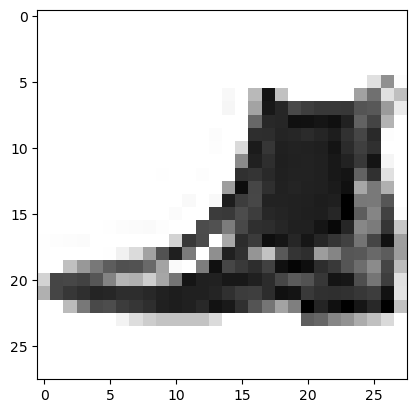

In [17]:
plt.imshow(X_train[5], cmap = 'binary')
plt.show()

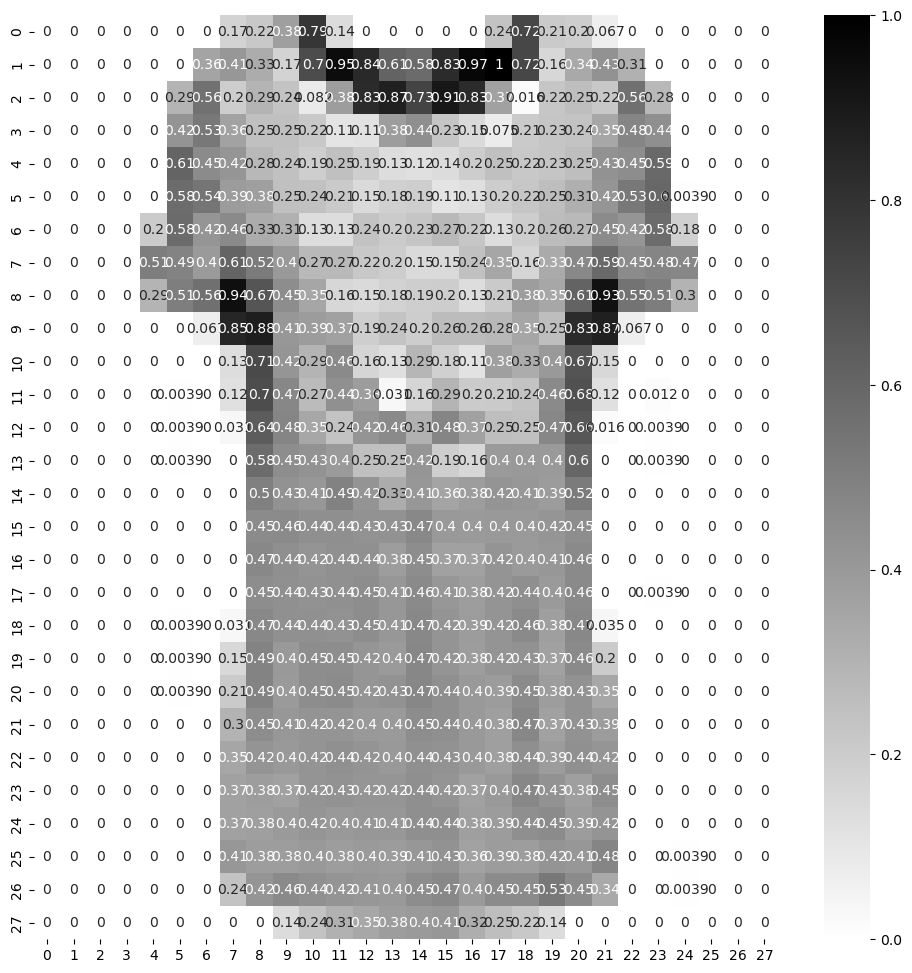

In [25]:
plt.figure(figsize=(12,12))
sns.heatmap(X_train[1],annot= True, cmap= 'binary' )
plt.show()

In [26]:
Layers = [keras.layers.Flatten(input_shape = [28,28], name = 'Input_Layer'),
          keras.layers.Dense(300, activation = 'relu', name = 'Hidden_Layer'),
          keras.layers.Dropout(0.2),
          keras.layers.Dense(100, activation = 'relu', name = 'Hidden_Layer2'),
          keras.layers.Dropout(0.2),
          keras.layers.Dense(10, activation= 'softmax', name = 'Output_Layer')
         ]

model = keras.models.Sequential(Layers)

In [27]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ Input_Layer (Flatten)                │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Hidden_Layer (Dense)                 │ (None, 300)                 │         235,500 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 300)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Hidden_Layer2 (Dense)                │ (None, 100)                 │          30,100 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 100)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Output_Layer (Dense)                 │ (None, 10)                  │           1,010 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

In [29]:
sgd_optimizers = tf.keras.optimizers.SGD(learning_rate= 0.01)

model.compile(loss= 'sparse_categorical_crossentropy', optimizer= sgd_optimizers, metrics= ['accuracy'])

sgd_history = model.fit(X_train,Y_train,  epochs= 10, validation_data= (X_valid, y_valid))

Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.5906 - loss: 1.1876 - val_accuracy: 0.8220 - val_loss: 0.5437
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.7929 - loss: 0.6036 - val_accuracy: 0.8408 - val_loss: 0.4589
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8214 - loss: 0.5171 - val_accuracy: 0.8520 - val_loss: 0.4236
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8316 - loss: 0.4784 - val_accuracy: 0.8612 - val_loss: 0.4002
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.8437 - loss: 0.4458 - val_accuracy: 0.8656 - val_loss: 0.3827
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8459 - loss: 0.4281 - val_accuracy: 0.8654 - val_loss: 0.3775
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 22s 7ms/step - accuracy: 0.8557 - loss: 0.4077 - val_accuracy: 0.8708 - val_loss: 0.3596
Epoch 8/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.8589 - loss: 0

In [31]:
model1 = keras.models.Sequential(Layers)
adam_Optimizers = tf.keras.optimizers.Adam(learning_rate= 0.001)

model1.compile(loss= 'sparse_categorical_crossentropy', optimizer= adam_Optimizers, metrics= ['accuracy'])

In [32]:
model.fit(X_train, Y_train, epochs= 10, validation_data= (X_valid, y_valid))

Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.8706 - loss: 0.3677 - val_accuracy: 0.8788 - val_loss: 0.3404
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.8731 - loss: 0.3586 - val_accuracy: 0.8814 - val_loss: 0.3304
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.8728 - loss: 0.3556 - val_accuracy: 0.8832 - val_loss: 0.3266
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.8786 - loss: 0.3422 - val_accuracy: 0.8820 - val_loss: 0.3242
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.8767 - loss: 0.3422 - val_accuracy: 0.8854 - val_loss: 0.3213
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.8790 - loss: 0.3369 - val_accuracy: 0.8872 - val_loss: 0.3147
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.8831 - loss: 0.3301 - val_accuracy: 0.8864 - val_loss: 0.3131
Epoch 8/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8833 - loss: 0

In [33]:
model1.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ Input_Layer (Flatten)                │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Hidden_Layer (Dense)                 │ (None, 300)                 │         235,500 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 300)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Hidden_Layer2 (Dense)                │ (None, 100)                 │          30,100 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 100)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Output_Layer (Dense)                 │ (None, 10)                  │           1,010 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

In [39]:
sgd.df = pd.DataFrame(sgd_history.history)

NameError: name 'sgd' is not defined